# Compute HDSBCAN clusters for pre- and post-QC feature spaces

We apply PCA first to the feature spaces before computing HDBSCAN.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine import (
    aes,
    element_text,
    facet_wrap,
    geom_bar,
    ggplot,
    guide_legend,
    guides,
    labs,
    position_stack,
    scale_fill_manual,
    theme,
    theme_bw,
)
from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA

# Ignore warning about deprecated argument name in sklearn
warnings.filterwarnings("ignore", message="'force_all_finite' was renamed")


In [2]:
# Output dir for figure
output_dir = pathlib.Path("./figures")
output_dir.mkdir(exist_ok=True, parents=True)

# Load in pre- and post-QC feature selected profiles
pre_QC_df = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected_no_QC.parquet"
    )
)
post_QC_df = pd.read_parquet(
    pathlib.Path(
        "/media/18tbdrive/1.Github_Repositories/cellpainting_predicts_cardiac_fibrosis/3.process_cfret_features/data/single_cell_profiles/localhost230405150001_sc_feature_selected.parquet"
    )
)
ECOD_df = pd.read_parquet(
    pathlib.Path(
        "./data/ecod_retransplant_norm_fs.parquet"
    )
)

# Metadata columns used to match rows across dataframes
metadata_cols = [
    "Metadata_Well",
    "Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
]

# --- coSMicQC pass/fail status ---
# Set all rows to failed first, then flip to passed where matched in post_QC_df
pre_QC_df["Metadata_coSMicQC_status"] = "failed"
coSMicQC_pass_index = post_QC_df.set_index(metadata_cols).index
coSMicQC_failed = ~pre_QC_df.set_index(metadata_cols).index.isin(coSMicQC_pass_index)
pre_QC_df.loc[~coSMicQC_failed, "Metadata_coSMicQC_status"] = "passed"

# --- ECOD pass/fail status ---
# ECOD_df contains only the rows that PASSED ECOD
pre_QC_df["Metadata_ECOD_status"] = "failed"
ecod_pass_index = ECOD_df.set_index(metadata_cols).index
ecod_failed = ~pre_QC_df.set_index(metadata_cols).index.isin(ecod_pass_index)
pre_QC_df.loc[~ecod_failed, "Metadata_ECOD_status"] = "passed"

# --- Combined status across both QC methods (vectorized, no function) ---
conditions = [
    coSMicQC_failed & ecod_failed,
    coSMicQC_failed & ~ecod_failed,
    ~coSMicQC_failed & ecod_failed,
]
choices = ["failed_both", "failed_coSMicQC_only", "failed_ECOD_only"]

pre_QC_df["Metadata_Combined_QC_status"] = np.select(
    conditions, choices, default="passed_both"
)

# --- Print counts ---
print(f"Total rows: {len(pre_QC_df)}")
print(f"Failed coSMicQC: {coSMicQC_failed.sum()}")
print(f"Failed ECOD: {ecod_failed.sum()}")
print("\nCombined status breakdown:")
print(pre_QC_df["Metadata_Combined_QC_status"].value_counts())

# Set min cluster size for HDBSCAN
min_cluster_size = 50


Total rows: 25859
Failed coSMicQC: 4994
Failed ECOD: 4991

Combined status breakdown:
Metadata_Combined_QC_status
passed_both             18211
failed_coSMicQC_only     2657
failed_ECOD_only         2654
failed_both              2337
Name: count, dtype: int64


## Compute individual scores

### Pre-QC UMAP scores

Total explained variance by first 5 PCs: 36.99%


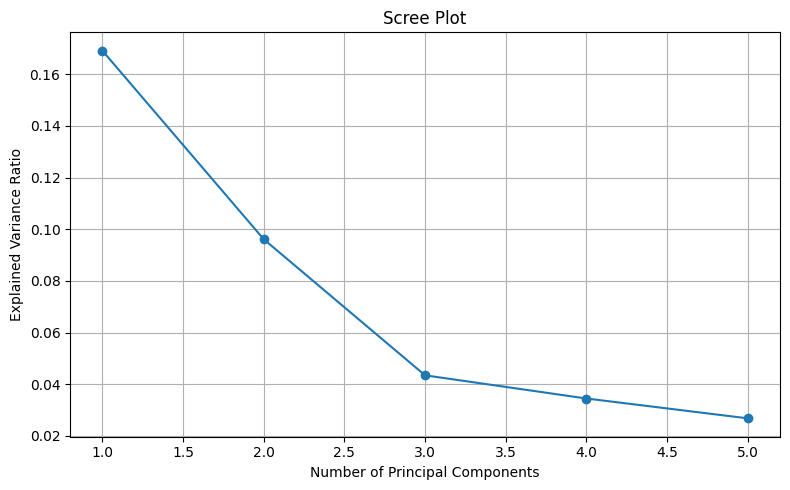

In [3]:
# Isolate just the feature space from Metadata in dataframe
pre_X = pre_QC_df.loc[:, ~pre_QC_df.columns.str.startswith("Metadata_")].values

# Run PCA on pre-QC feature space
pca = PCA(n_components=5, random_state=0)
pre_QC_pca = pca.fit_transform(pre_X)

# Print the total explained variance percentage for the first 5 PCs
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Total explained variance by first 5 PCs: {explained_variance:.2f}%")

# Create scree plot to show variance explained by each PC
plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.tight_layout()
plt.show()


In [4]:
# Run HDBSCAN using sklearn compatible interface
clusterer = HDBSCAN(min_cluster_size=min_cluster_size, n_jobs=-1)
pre_cluster_labels = clusterer.fit_predict(pre_QC_pca)

# Attach cluster labels to the original dataframe
pre_QC_df["cluster"] = pre_cluster_labels

# Info about clusters
print("Unique cluster labels (-1 is noise):", np.unique(pre_cluster_labels))

# Make a dataframe for enrichment analysis: only metadata + cluster label
metadata_cols = [col for col in pre_QC_df.columns if col.startswith("Metadata_")]
pre_enrichment_df = pre_QC_df[[*metadata_cols, "cluster"]].copy()

# Exclude noise points if you want enrichment only on real clusters
pre_enrichment_df = pre_enrichment_df[pre_enrichment_df["cluster"] != -1]
print(pre_enrichment_df.shape)
pre_enrichment_df.head()


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.


Unique cluster labels (-1 is noise): [-1  0  1]
(18524, 23)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,Metadata_coSMicQC_status,Metadata_ECOD_status,Metadata_Combined_QC_status,cluster
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,...,B02,1,1,6,6,f00,passed,passed,passed_both,0
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,...,B02,2,2,7,7,f00,passed,passed,passed_both,0
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,B02,3,3,8,8,f00,passed,passed,passed_both,0
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,...,B02,4,4,9,9,f00,passed,passed,passed_both,0
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,...,B02,5,5,10,10,f00,passed,passed,passed_both,0


### Post-QC UMAP scores

Total explained variance by first 5 PCs: 32.96%


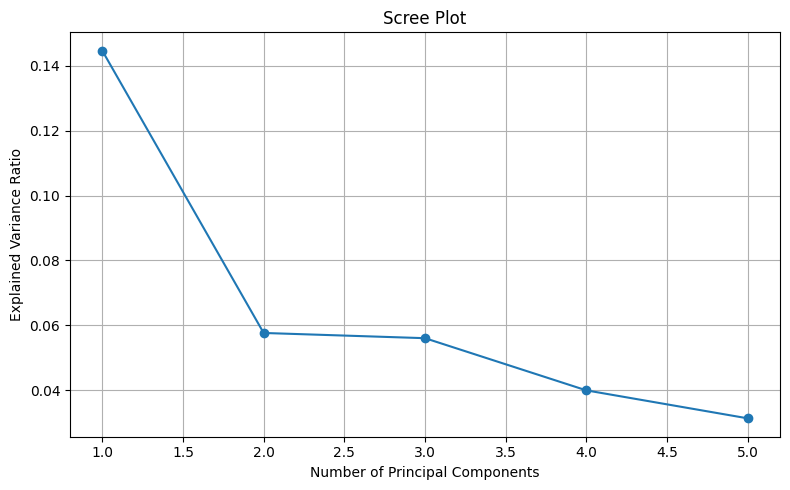

In [5]:
# Isolate just the feature space from Metadata in dataframe
post_X = post_QC_df.loc[:, ~post_QC_df.columns.str.startswith("Metadata_")].values

# Run PCA on post-QC feature space
pca = PCA(n_components=5, random_state=0)
post_QC_pca = pca.fit_transform(post_X)

# Print the total explained variance percentage for the first 5 PCs
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Total explained variance by first 5 PCs: {explained_variance:.2f}%")

# Create scree plot to show variance explained by each PC
plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.tight_layout()
plt.show()


In [6]:
# Run HDBSCAN using sklearn compatible interface
clusterer = HDBSCAN(min_cluster_size=min_cluster_size, n_jobs=-1)
post_cluster_labels = clusterer.fit_predict(post_QC_pca)

# Attach cluster labels to the original dataframe
post_QC_df["cluster"] = post_cluster_labels

# Info about clusters
print("Unique cluster labels (-1 is noise):", np.unique(post_cluster_labels))

# Make a dataframe for enrichment analysis: only metadata + cluster label
metadata_cols = [col for col in post_QC_df.columns if col.startswith("Metadata_")]
post_enrichment_df = post_QC_df[[*metadata_cols, "cluster"]].copy()

# Exclude noise points if you want enrichment only on real clusters
post_enrichment_df = post_enrichment_df[post_enrichment_df["cluster"] != -1]
print(post_enrichment_df.shape)
post_enrichment_df.head()


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.


Unique cluster labels (-1 is noise): [-1  0  1  2]
(1450, 20)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Metadata_Plate,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Metadata_Site,cluster
16,B,2,9,failing,rejected,DMSO,837.084276,552.947398,840.452522,540.446958,40,1,localhost230405150001,B02,19,19,26,26,f00,1
19,B,2,9,failing,rejected,DMSO,804.752274,625.758159,789.908604,638.665591,40,1,localhost230405150001,B02,22,22,31,31,f00,1
27,B,2,9,failing,rejected,DMSO,735.961026,834.631475,754.307418,799.787045,40,1,localhost230405150001,B02,30,30,41,41,f00,1
28,B,2,9,failing,rejected,DMSO,916.114325,837.045914,921.676069,845.036480,40,1,localhost230405150001,B02,31,31,42,42,f00,1
30,B,2,9,failing,rejected,DMSO,551.152184,874.413763,520.770840,862.416540,40,1,localhost230405150001,B02,33,33,44,44,f00,1


## Post PyOD ECOD scores

Total explained variance by first 5 PCs: 33.91%


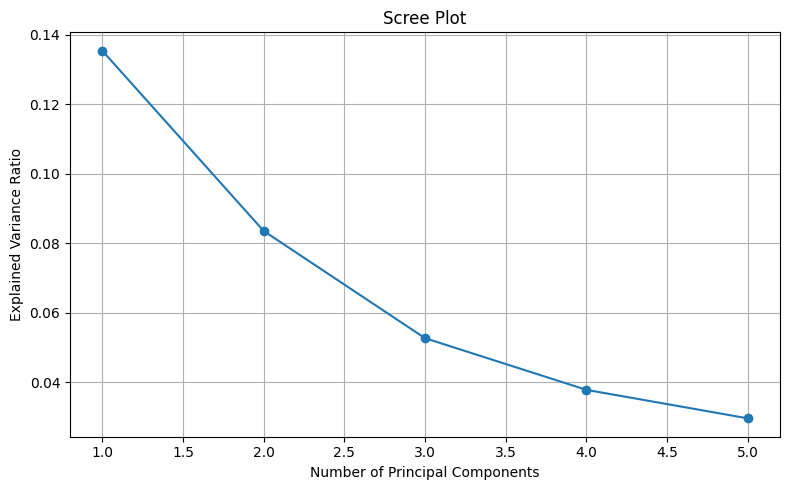

In [7]:
# Isolate just the feature space from Metadata in dataframe
PyOD_ECOD_X = ECOD_df.loc[:, ~ECOD_df.columns.str.startswith(("Metadata_", "Image_"))].values

# Run PCA on post-QC feature space
pca = PCA(n_components=5, random_state=0)
post_ECOD_pca = pca.fit_transform(PyOD_ECOD_X)

# Print the total explained variance percentage for the first 5 PCs
explained_variance = np.sum(pca.explained_variance_ratio_) * 100
print(f"Total explained variance by first 5 PCs: {explained_variance:.2f}%")

# Create scree plot to show variance explained by each PC
plt.figure(figsize=(8, 5))
plt.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o",
)
plt.xlabel("Number of Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid()
plt.tight_layout()
plt.show()


In [8]:
# Run HDBSCAN using sklearn compatible interface
clusterer = HDBSCAN(min_cluster_size=min_cluster_size, n_jobs=-1)
post_ECOD_cluster_labels = clusterer.fit_predict(post_ECOD_pca)

# Attach cluster labels to the original dataframe
ECOD_df["cluster"] = post_ECOD_cluster_labels

# Info about clusters
print("Unique cluster labels (-1 is noise):", np.unique(post_ECOD_cluster_labels))

# Make a dataframe for enrichment analysis: only metadata + cluster label
metadata_cols = [col for col in ECOD_df.columns if col.startswith(("Metadata_", "Image_"))]
post_ECOD_enrichment_df = ECOD_df[[*metadata_cols, "cluster"]].copy()

# Exclude noise points if you want enrichment only on real clusters
post_ECOD_enrichment_df = post_ECOD_enrichment_df[post_ECOD_enrichment_df["cluster"] != -1]
print(post_ECOD_enrichment_df.shape)
post_ECOD_enrichment_df.head()


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.


Unique cluster labels (-1 is noise): [-1  0  1]
(16719, 22)


,Metadata_WellRow,Metadata_WellCol,Metadata_heart_number,Metadata_cell_type,Metadata_heart_failure_type,Metadata_treatment,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,...,Metadata_Plate,Metadata_Site,Metadata_Well,Metadata_Cells_Number_Object_Number,Metadata_Cytoplasm_Parent_Cells,Metadata_Cytoplasm_Parent_Nuclei,Metadata_Nuclei_Number_Object_Number,Image_FileName_Hoechst,Image_FileName_Actin,cluster
0,B,2,9,failing,rejected,DMSO,221.046761,137.115493,246.602800,109.285755,...,localhost230405150001,f00,B02,1,1,6,6,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,0
1,B,2,9,failing,rejected,DMSO,690.596142,183.067828,716.170091,177.132195,...,localhost230405150001,f00,B02,2,2,7,7,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,0
2,B,2,9,failing,rejected,DMSO,626.561490,206.923698,623.943740,199.906440,...,localhost230405150001,f00,B02,3,3,8,8,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,0
3,B,2,9,failing,rejected,DMSO,559.448583,220.688160,528.646623,196.955552,...,localhost230405150001,f00,B02,4,4,9,9,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,0
4,B,2,9,failing,rejected,DMSO,909.019946,247.694340,897.965996,253.621836,...,localhost230405150001,f00,B02,5,5,10,10,localhost230405150001_B02f00d0_illumcorrect.tiff,localhost230405150001_B02f00d4_illumcorrect.tiff,0


# Visualize where passing or failing cells are within each cluster

cluster
0    17530
1      994
Name: count, dtype: int64


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 8 x 5 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/pre_QC_cluster_qc_status_proportions.png


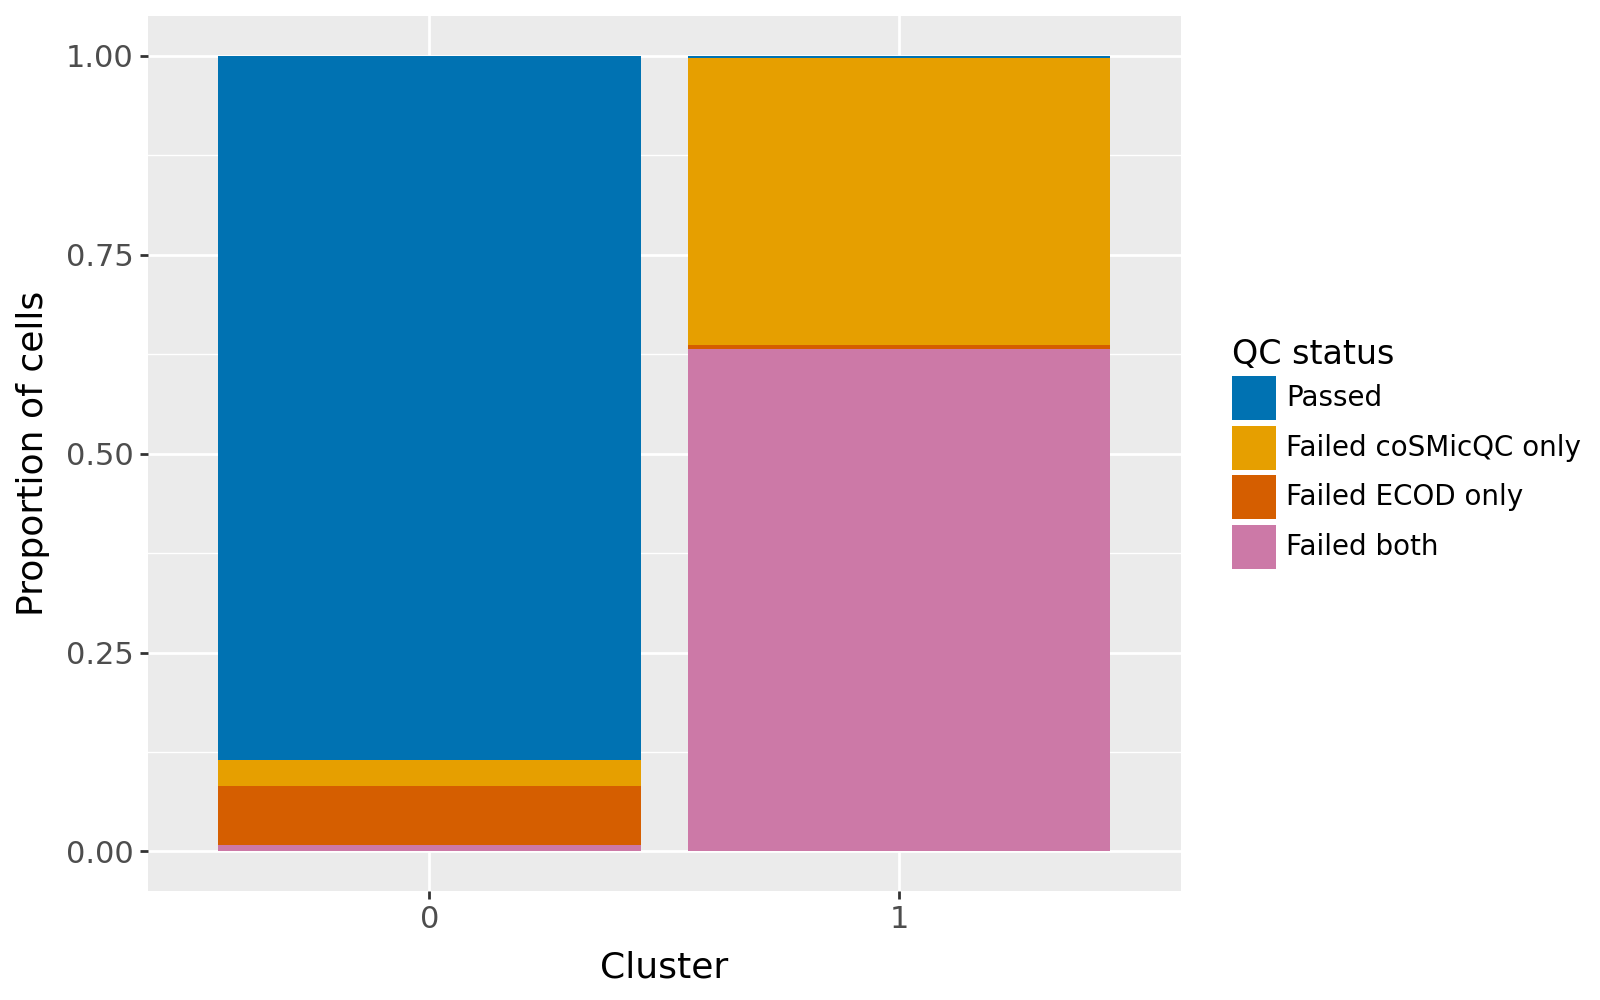

In [9]:
# Attach cluster labels to full dataframe
pre_QC_clusters_df = pre_QC_df.copy()
pre_QC_clusters_df["cluster"] = pre_cluster_labels

# Drop noise
pre_QC_clusters_df = pre_QC_clusters_df[pre_QC_clusters_df["cluster"] != -1]

# Convert labels to string for nicer plotting
pre_QC_clusters_df["cluster"] = pre_QC_clusters_df["cluster"].astype(str)

# Print number of cells in each cluster
print(pre_QC_clusters_df["cluster"].value_counts().sort_index())

# Friendly labels for the combined QC status categories
qc_status_display_map = {
    "passed_both": "Passed",
    "failed_coSMicQC_only": "Failed coSMicQC only",
    "failed_ECOD_only": "Failed ECOD only",
    "failed_both": "Failed both",
}
qc_status_order = [
    "Passed",
    "Failed coSMicQC only",
    "Failed ECOD only",
    "Failed both",
]
qc_status_palette = {
    "Passed": "#0072B2",
    "Failed coSMicQC only": "#E69F00",
    "Failed ECOD only": "#D55E00",
    "Failed both": "#CC79A7",
}

pre_QC_clusters_df["QC_status"] = pre_QC_clusters_df["Metadata_Combined_QC_status"].map(
    qc_status_display_map
)

# Calculate proportions for each cluster
cluster_counts = (
    pre_QC_clusters_df.groupby(["cluster", "QC_status"])
    .size()
    .unstack(fill_value=0)
)
cluster_props = (
    cluster_counts.div(cluster_counts.sum(axis=1), axis=0)
    .reset_index()
    .melt(id_vars="cluster", var_name="QC_status", value_name="proportion")
)
cluster_props["QC_status"] = pd.Categorical(
    cluster_props["QC_status"], categories=qc_status_order, ordered=True
)

# Plot
p = (
    ggplot(cluster_props, aes(x="cluster", y="proportion", fill="QC_status"))
    + geom_bar(stat="identity", position=position_stack())
    + scale_fill_manual(values=qc_status_palette)
    + labs(
        x="Cluster",
        y="Proportion of cells",
        fill="QC status",
    )
    + theme(
        figure_size=(8, 5),
        axis_text_x=element_text(size=11),
        axis_text_y=element_text(size=11),
        axis_title_x=element_text(size=13),
        axis_title_y=element_text(size=13),
        legend_title=element_text(size=12),
        legend_text=element_text(size=10),
    )
)

p.save(output_dir / "pre_QC_cluster_qc_status_proportions.png", dpi=300)
p.show()


cluster
0     265
1    1050
2     135
Name: count, dtype: int64


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/post_QC_cluster_treatment_celltype.png


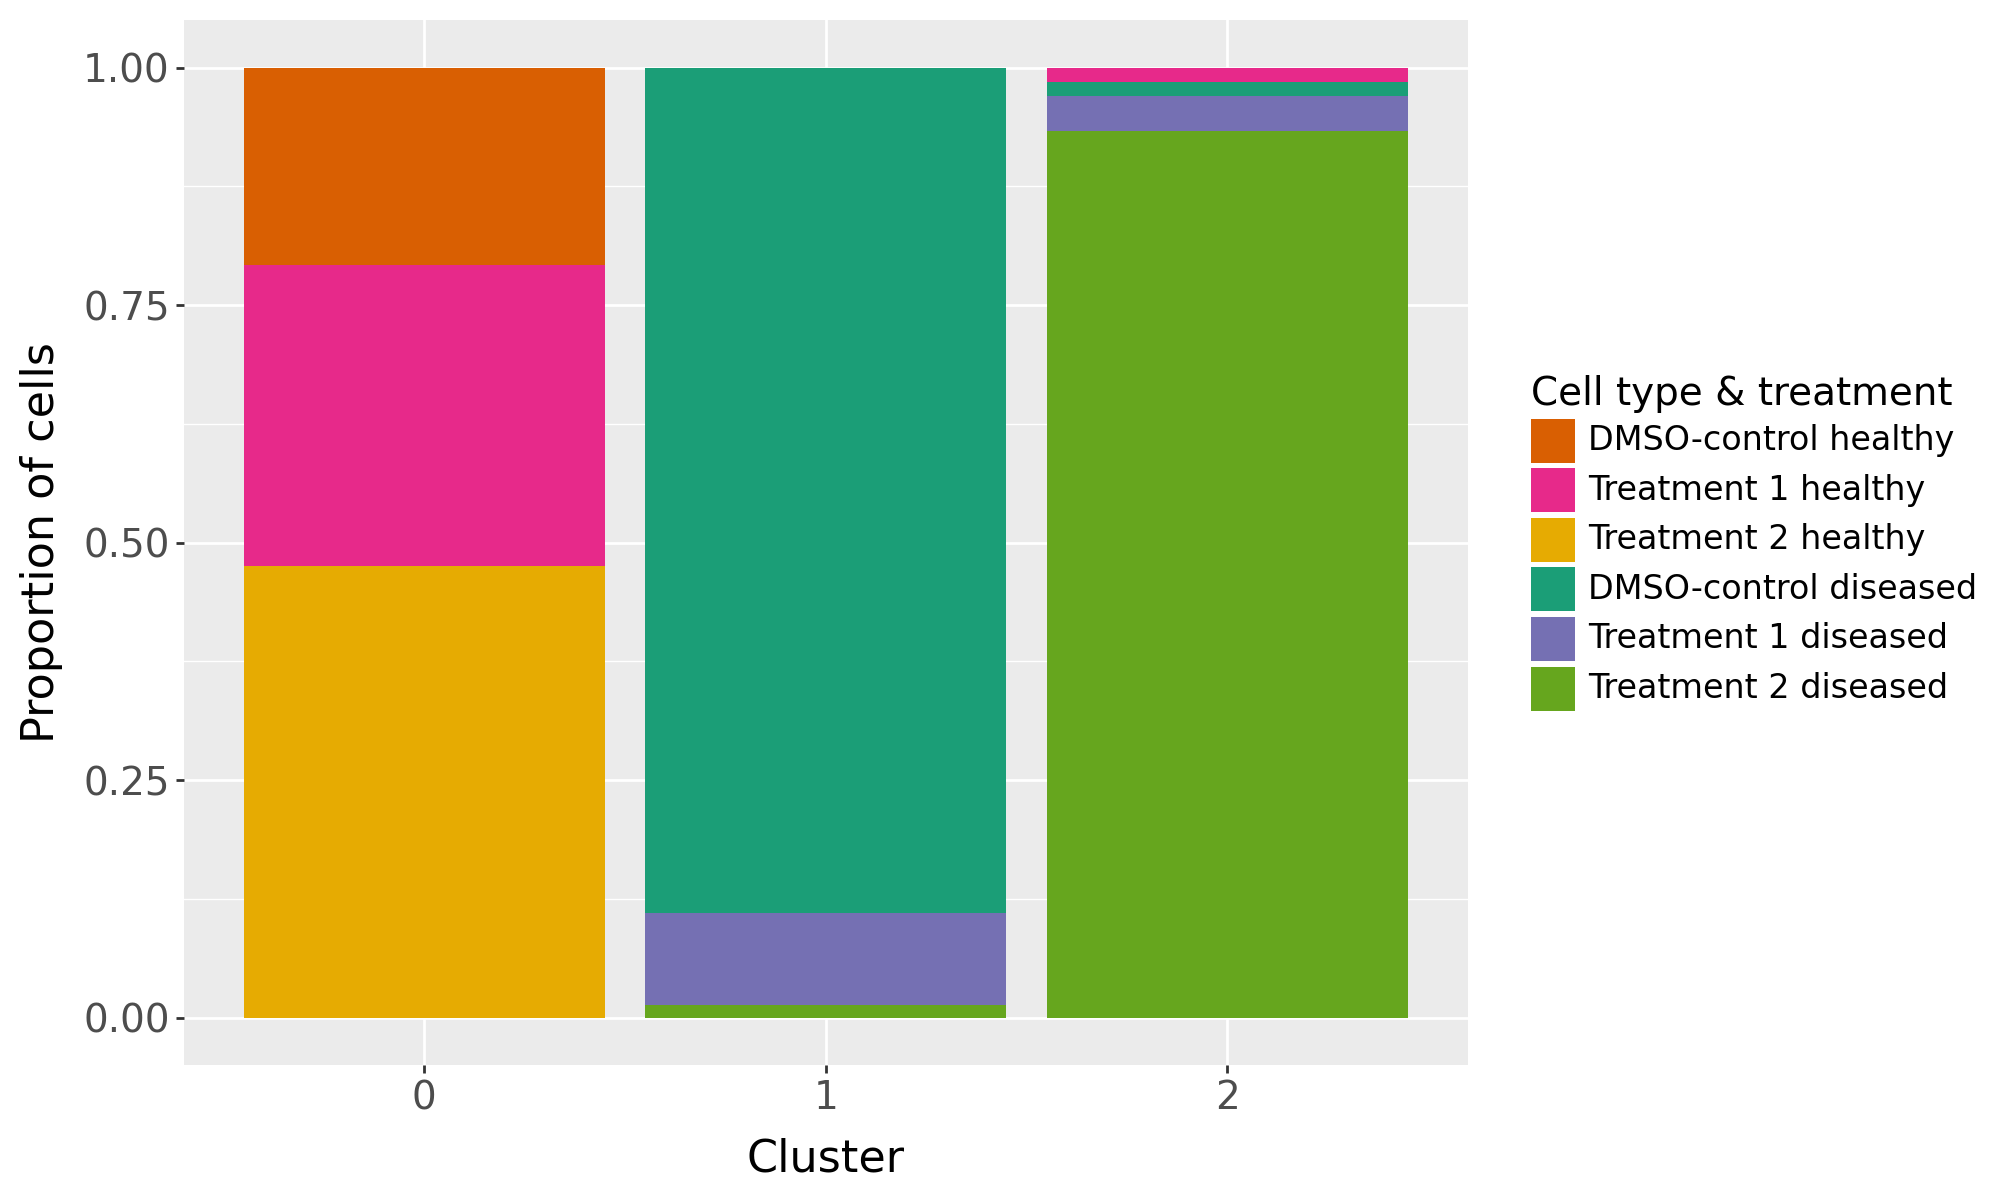

In [10]:
# Attach cluster labels to full dataframe
post_QC_clusters_df = post_QC_df.copy()
post_QC_clusters_df["cluster"] = post_cluster_labels

# Drop noise
post_QC_clusters_df = post_QC_clusters_df[post_QC_clusters_df["cluster"] != -1]

# Convert labels to string for nicer plotting
post_QC_clusters_df["cluster"] = post_QC_clusters_df["cluster"].astype(str)

# Print number of cells in each cluster
print(post_QC_clusters_df["cluster"].value_counts().sort_index())

# Prepare data
plot_df = (
    post_QC_clusters_df.groupby(["cluster", "Metadata_treatment", "Metadata_cell_type"])
    .size()
    .reset_index(name="count")
)

# Calculate proportion per cluster
plot_df["proportion"] = plot_df.groupby("cluster")["count"].transform(
    lambda x: x / x.sum()
)

# Blind treatments (matching naming used in the panelB UMAP plot)
treatment_blind_map = {
    "DMSO": "control",
    "TGFRi": "treatment1",
    "drug_x": "treatment2",
}
plot_df["Metadata_treatment"] = plot_df["Metadata_treatment"].map(treatment_blind_map)

# Rename cell type labels to match paper terminology (failing -> diseased)
celltype_display_map = {
    "healthy": "healthy",
    "failing": "diseased",
}
plot_df["Metadata_cell_type"] = plot_df["Metadata_cell_type"].map(celltype_display_map)

# Combine treatment and cell type, then apply the same plain-English labels
# used for the legend in the panelB UMAP plot (no "|" separator)
plot_df["treatment_celltype"] = (
    plot_df["Metadata_treatment"] + "_" + plot_df["Metadata_cell_type"]
).replace(
    {
        "control_diseased": "DMSO-control diseased",
        "treatment1_diseased": "Treatment 1 diseased",
        "treatment2_diseased": "Treatment 2 diseased",
        "control_healthy": "DMSO-control healthy",
        "treatment1_healthy": "Treatment 1 healthy",
        "treatment2_healthy": "Treatment 2 healthy",
    }
)

# Palette matching the colors used for each treatment/cell-type combo in the
# panelB UMAP plot (colorbrewer "Dark2" qualitative palette)
palette_dict = {
    "DMSO-control diseased": "#1B9E77",
    "DMSO-control healthy": "#D95F02",
    "Treatment 1 diseased": "#7570B3",
    "Treatment 1 healthy": "#E7298A",
    "Treatment 2 diseased": "#66A61E",
    "Treatment 2 healthy": "#E6AB02",
}

# Set categorical order with blinded names
desired_order = [
    "DMSO-control healthy",
    "Treatment 1 healthy",
    "Treatment 2 healthy",
    "DMSO-control diseased",
    "Treatment 1 diseased",
    "Treatment 2 diseased",
]
plot_df["treatment_celltype"] = pd.Categorical(
    plot_df["treatment_celltype"], categories=desired_order, ordered=True
)


# Plot
p = (
    ggplot(plot_df, aes(x="cluster", y="proportion", fill="treatment_celltype"))
    + geom_bar(stat="identity", position=position_stack())
    + scale_fill_manual(values=palette_dict, name="Cell type & treatment")
    + labs(
        x="Cluster",
        y="Proportion of cells",
    )
    + theme(
        figure_size=(10, 6),
        axis_text_x=element_text(size=14),
        axis_text_y=element_text(size=14),
        axis_title_x=element_text(size=16),
        axis_title_y=element_text(size=16),
        legend_title=element_text(size=14),
        legend_text=element_text(size=12),
    )
)

p.save(output_dir / "post_QC_cluster_treatment_celltype.png", dpi=300)
p


cluster
0    16290
1      429
Name: count, dtype: int64


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:623: PlotnineWarning: Saving 10 x 6 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:624: PlotnineWarning: Filename: figures/ecod_cluster_treatment_celltype.png


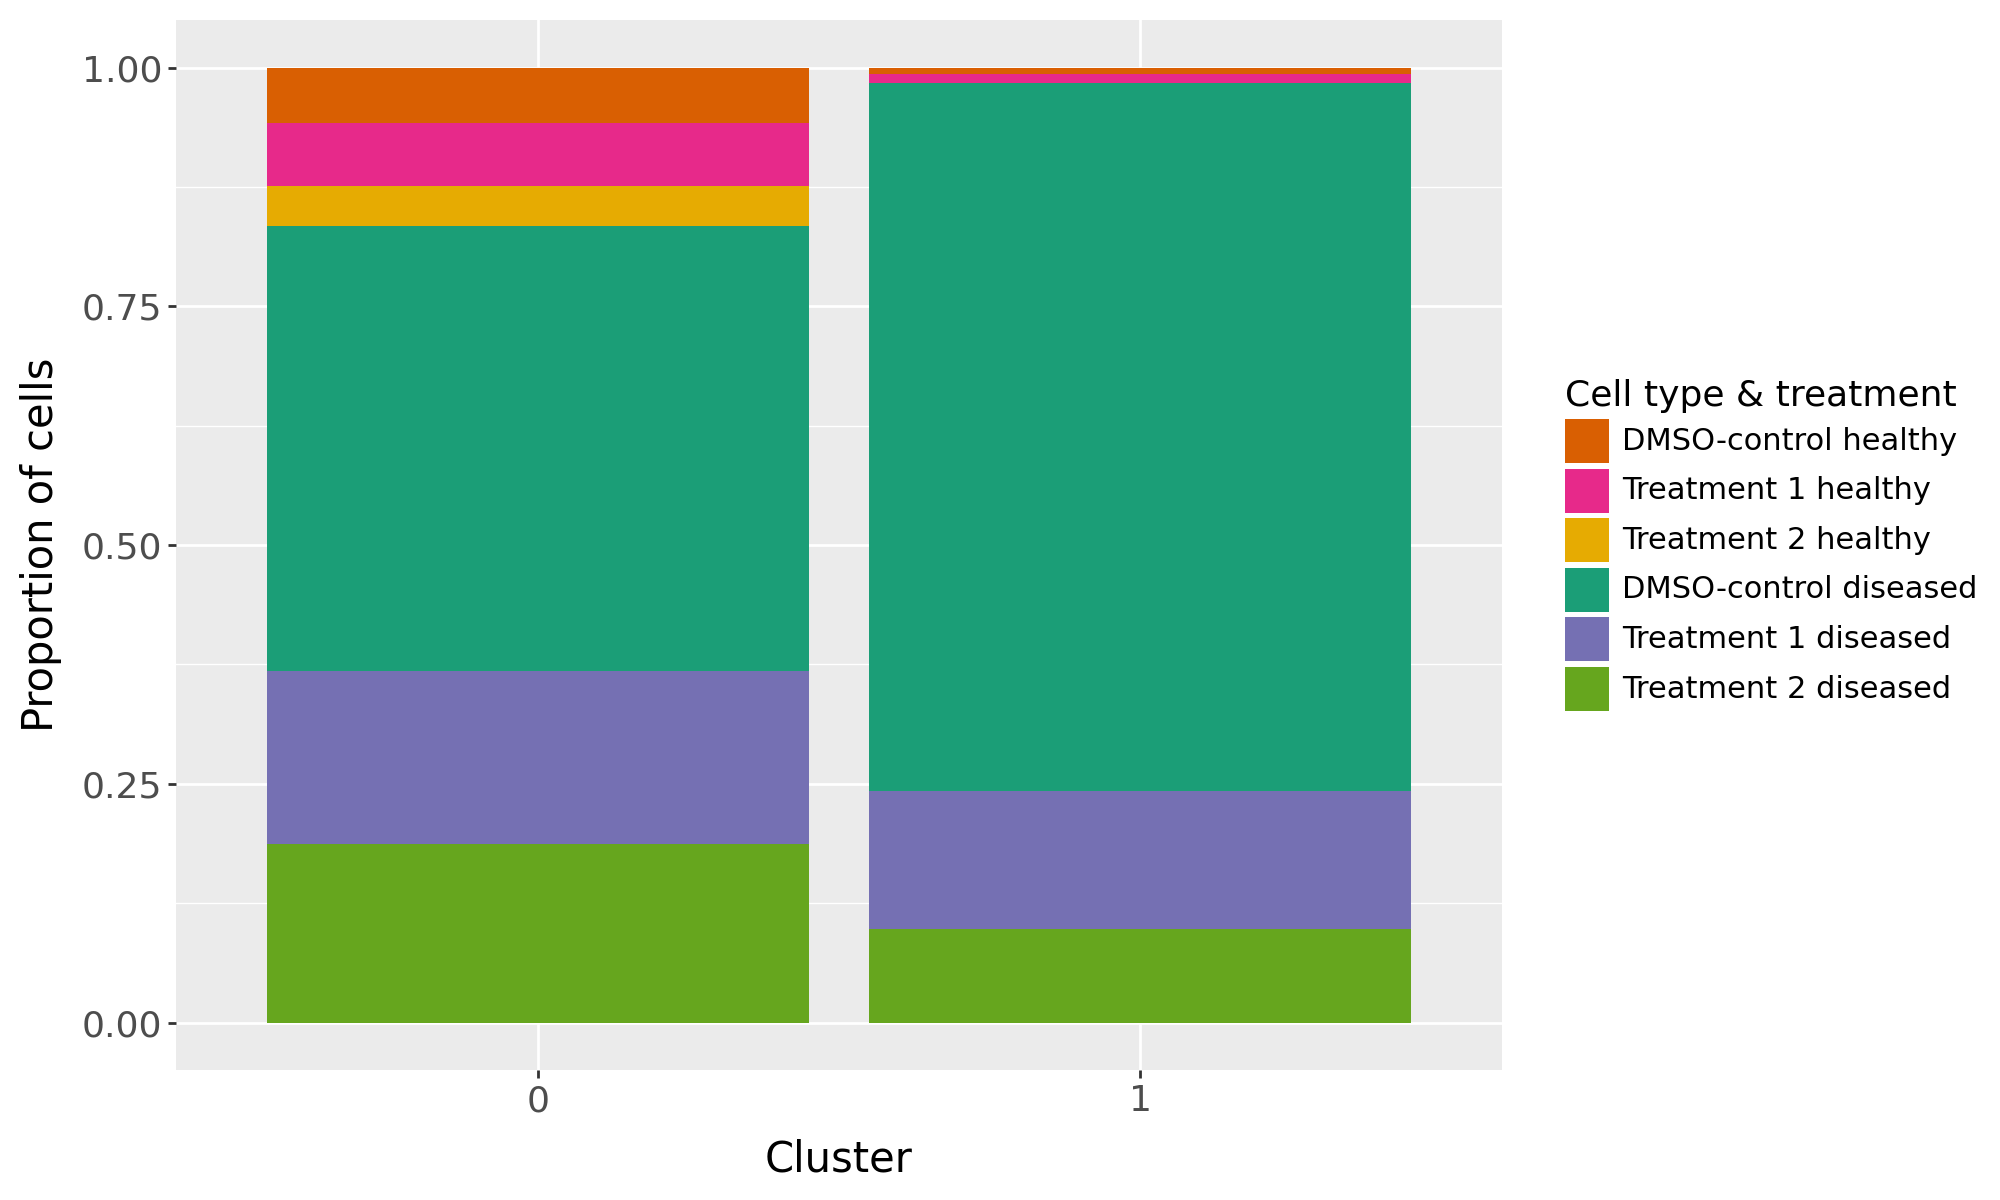

In [11]:
# Attach cluster labels to full dataframe
ecod_clusters_df = ECOD_df.copy()
ecod_clusters_df["cluster"] = post_ECOD_cluster_labels

# Drop noise
ecod_clusters_df = ecod_clusters_df[ecod_clusters_df["cluster"] != -1]

# Convert labels to string for nicer plotting
ecod_clusters_df["cluster"] = ecod_clusters_df["cluster"].astype(str)

# Print number of cells in each cluster
print(ecod_clusters_df["cluster"].value_counts().sort_index())

# Prepare data
plot_df = (
    ecod_clusters_df.groupby(["cluster", "Metadata_treatment", "Metadata_cell_type"])
    .size()
    .reset_index(name="count")
)

# Calculate proportion per cluster
plot_df["proportion"] = plot_df.groupby("cluster")["count"].transform(
    lambda x: x / x.sum()
)

# Blind treatments (matching naming used in the panelB UMAP plot)
treatment_blind_map = {
    "DMSO": "control",
    "TGFRi": "treatment1",
    "drug_x": "treatment2",
}
plot_df["Metadata_treatment"] = plot_df["Metadata_treatment"].map(treatment_blind_map)

# Rename cell type labels to match paper terminology (failing -> diseased)
celltype_display_map = {
    "healthy": "healthy",
    "failing": "diseased",
}
plot_df["Metadata_cell_type"] = plot_df["Metadata_cell_type"].map(celltype_display_map)

# Combine treatment and cell type, then apply the same plain-English labels
# used for the legend in the panelB UMAP plot (no "|" separator)
plot_df["treatment_celltype"] = (
    plot_df["Metadata_treatment"] + "_" + plot_df["Metadata_cell_type"]
).replace(
    {
        "control_diseased": "DMSO-control diseased",
        "treatment1_diseased": "Treatment 1 diseased",
        "treatment2_diseased": "Treatment 2 diseased",
        "control_healthy": "DMSO-control healthy",
        "treatment1_healthy": "Treatment 1 healthy",
        "treatment2_healthy": "Treatment 2 healthy",
    }
)

# Palette matching the colors used for each treatment/cell-type combo in the
# panelB UMAP plot (colorbrewer "Dark2" qualitative palette)
palette_dict = {
    "DMSO-control diseased": "#1B9E77",
    "DMSO-control healthy": "#D95F02",
    "Treatment 1 diseased": "#7570B3",
    "Treatment 1 healthy": "#E7298A",
    "Treatment 2 diseased": "#66A61E",
    "Treatment 2 healthy": "#E6AB02",
}

# Set categorical order with blinded names
desired_order = [
    "DMSO-control healthy",
    "Treatment 1 healthy",
    "Treatment 2 healthy",
    "DMSO-control diseased",
    "Treatment 1 diseased",
    "Treatment 2 diseased",
]
plot_df["treatment_celltype"] = pd.Categorical(
    plot_df["treatment_celltype"], categories=desired_order, ordered=True
)


# Plot
p = (
    ggplot(plot_df, aes(x="cluster", y="proportion", fill="treatment_celltype"))
    + geom_bar(stat="identity", position=position_stack())
    + scale_fill_manual(values=palette_dict, name="Cell type & treatment")
    + labs(
        x="Cluster",
        y="Proportion of cells",
    )
    + theme(
        figure_size=(10, 6),
        axis_text_x=element_text(size=13),
        axis_text_y=element_text(size=13),
        axis_title_x=element_text(size=15),
        axis_title_y=element_text(size=15),
        legend_title=element_text(size=13),
        legend_text=element_text(size=11),
    )
)

p.save(output_dir / "ecod_cluster_treatment_celltype.png", dpi=300)
p


## Combined view: cluster composition faceted by QC condition

Consolidate the three cluster-composition plots above into a single figure that
facets by QC condition (Pre-QC, Post-QC: coSMicQC, Post-QC: ECOD), using a
consistent treatment | cell type fill/palette across all panels so the
clusters are directly comparable.

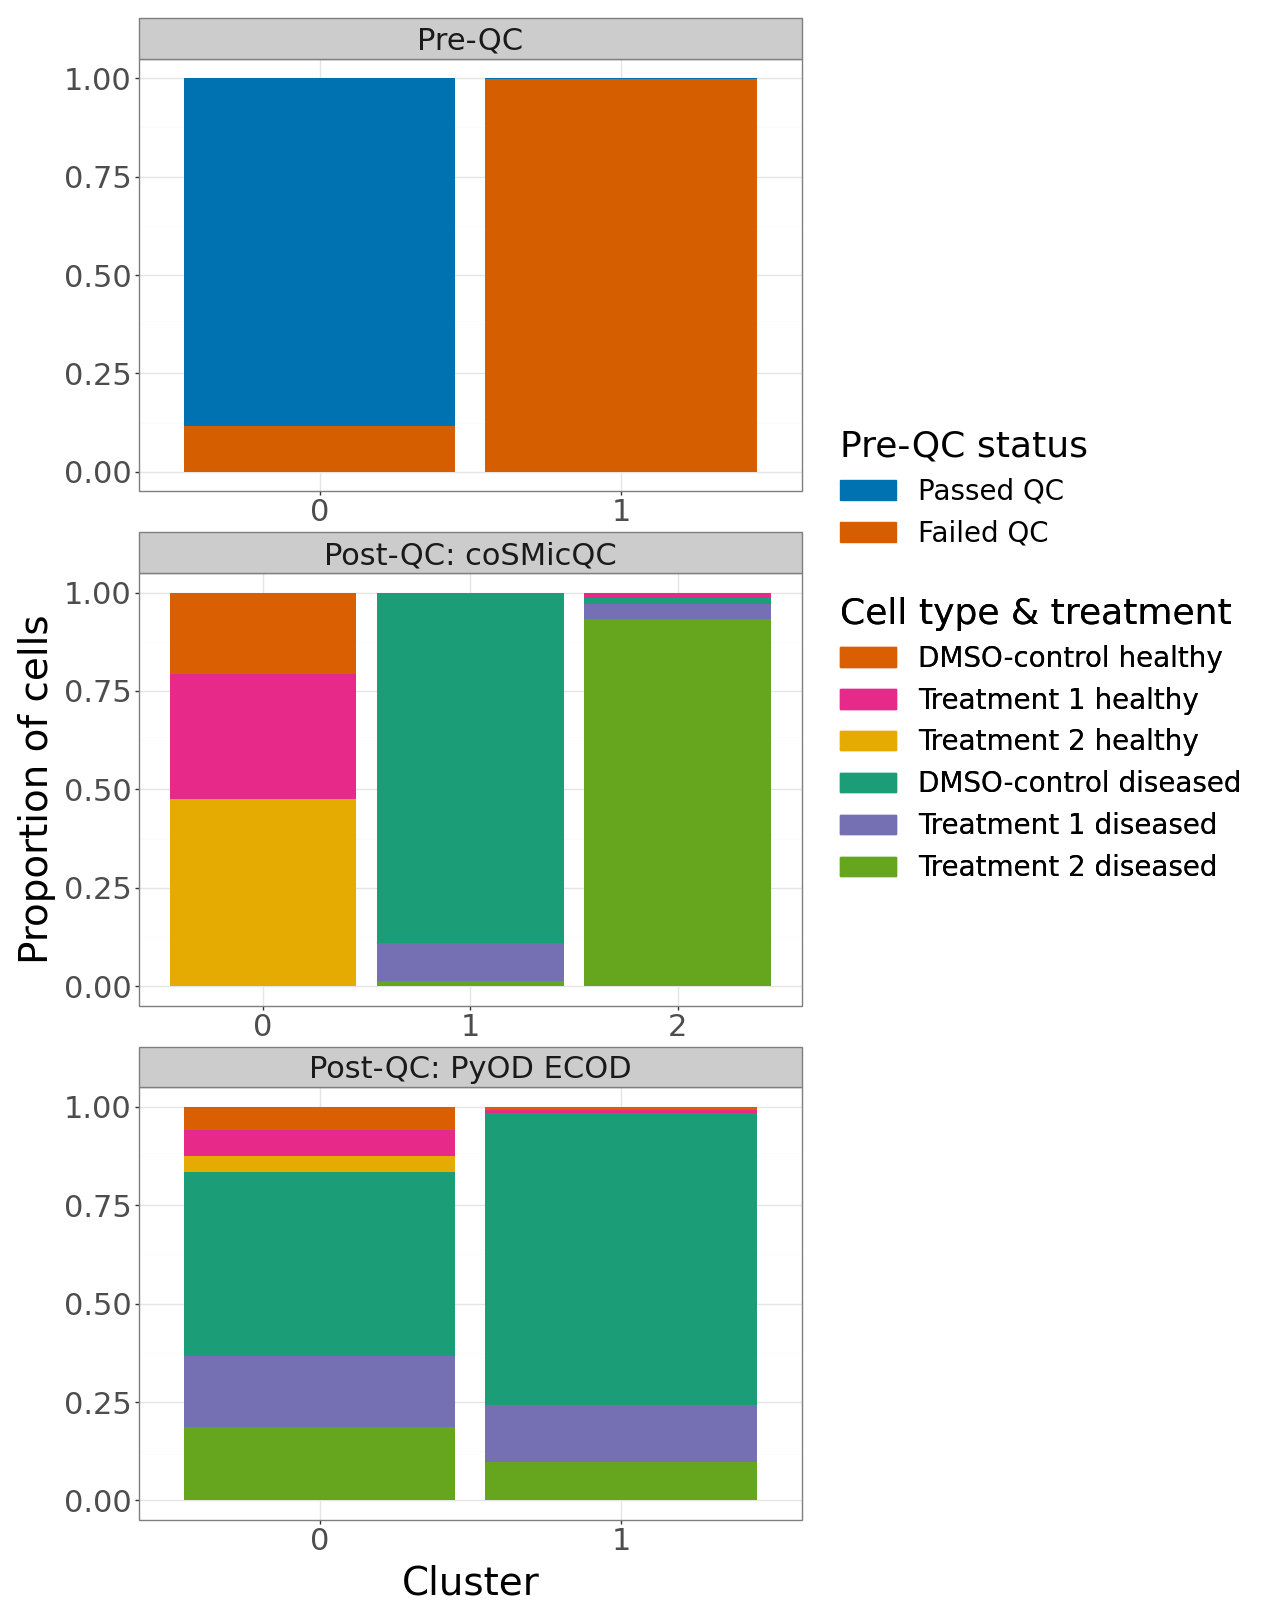

In [12]:
import matplotlib.patches as mpatches

# Shared blinding / display maps used across the two post-QC conditions
# (matching naming used in the panelB UMAP plot)
treatment_blind_map = {
    "DMSO": "control",
    "TGFRi": "treatment1",
    "drug_x": "treatment2",
}
celltype_display_map = {
    "healthy": "healthy",
    "failing": "diseased",
}
treatment_celltype_display_map = {
    "control_diseased": "DMSO-control diseased",
    "treatment1_diseased": "Treatment 1 diseased",
    "treatment2_diseased": "Treatment 2 diseased",
    "control_healthy": "DMSO-control healthy",
    "treatment1_healthy": "Treatment 1 healthy",
    "treatment2_healthy": "Treatment 2 healthy",
}

# Palette matching the colors used for each treatment/cell-type combo in the
# panelB UMAP plot (colorbrewer "Dark2" qualitative palette via
# scale_color_brewer(type="qual", palette="Dark2"), which assigns colors in
# alphabetical category order since Metadata_Treatment_CellType_ID isn't
# explicitly ordered there)
treatment_celltype_palette = {
    "DMSO-control diseased": "#1B9E77",
    "DMSO-control healthy": "#D95F02",
    "Treatment 1 diseased": "#7570B3",
    "Treatment 1 healthy": "#E7298A",
    "Treatment 2 diseased": "#66A61E",
    "Treatment 2 healthy": "#E6AB02",
}
desired_order = [
    "DMSO-control healthy",
    "Treatment 1 healthy",
    "Treatment 2 healthy",
    "DMSO-control diseased",
    "Treatment 1 diseased",
    "Treatment 2 diseased",
]

# Pre-QC pass/fail palette: a cell counts as "Failed" if it failed either
# coSMicQC or PyOD ECOD (i.e. anything other than "passed_both")
qc_status_palette = {
    "Passed QC": "#0072B2",  # blue
    "Failed QC": "#D55E00",  # orange
}
qc_status_order = ["Passed QC", "Failed QC"]

# Single fill scale spanning both category sets so the bars render with the
# right colors; the automatic combined legend is suppressed below in favor
# of two separate legends (QC status, and cell type & treatment)
fill_palette = {**qc_status_palette, **treatment_celltype_palette}
fill_order = qc_status_order + desired_order

# Pre-QC facet: proportions per cluster, filled by combined pass/fail QC status
pre_qc_plot_df = (
    pre_QC_clusters_df.assign(
        fill_group=np.where(
            pre_QC_clusters_df["Metadata_Combined_QC_status"] == "passed_both",
            "Passed QC",
            "Failed QC",
        )
    )
    .groupby(["cluster", "fill_group"])
    .size()
    .reset_index(name="count")
)
pre_qc_plot_df["proportion"] = pre_qc_plot_df.groupby("cluster")["count"].transform(
    lambda x: x / x.sum()
)
pre_qc_plot_df["QC_condition"] = "Pre-QC"
pre_qc_plot_df = pre_qc_plot_df[["cluster", "fill_group", "proportion", "QC_condition"]]

# Post-QC facets: proportions per cluster, filled by treatment/cell-type
post_qc_condition_dfs = {
    "Post-QC: coSMicQC": post_QC_clusters_df,
    "Post-QC: PyOD ECOD": ecod_clusters_df,
}

post_qc_plot_df_list = []
for qc_condition, clusters_df in post_qc_condition_dfs.items():
    plot_df = (
        clusters_df.groupby(["cluster", "Metadata_treatment", "Metadata_cell_type"])
        .size()
        .reset_index(name="count")
    )
    plot_df["proportion"] = plot_df.groupby("cluster")["count"].transform(
        lambda x: x / x.sum()
    )

    plot_df["Metadata_treatment"] = plot_df["Metadata_treatment"].map(
        treatment_blind_map
    )
    plot_df["Metadata_cell_type"] = plot_df["Metadata_cell_type"].map(
        celltype_display_map
    )
    plot_df["fill_group"] = (
        plot_df["Metadata_treatment"] + "_" + plot_df["Metadata_cell_type"]
    ).replace(treatment_celltype_display_map)
    plot_df["QC_condition"] = qc_condition
    post_qc_plot_df_list.append(
        plot_df[["cluster", "fill_group", "proportion", "QC_condition"]]
    )

combined_plot_df = pd.concat(
    [pre_qc_plot_df, *post_qc_plot_df_list], ignore_index=True
)
combined_plot_df["fill_group"] = pd.Categorical(
    combined_plot_df["fill_group"], categories=fill_order, ordered=True
)
combined_plot_df["QC_condition"] = pd.Categorical(
    combined_plot_df["QC_condition"],
    categories=["Pre-QC", "Post-QC: coSMicQC", "Post-QC: PyOD ECOD"],
    ordered=True,
)

# Plot: one faceted figure in place of the three separate cluster plots above.
# Pre-QC facet is colored by pass/fail QC status; post-QC facets are colored
# by treatment/cell-type (same colors as the panelB UMAP plot). The built-in
# fill legend is suppressed since it would merge both category sets into a
# single legend; two separate legends are drawn manually below instead.
p = (
    ggplot(
        combined_plot_df, aes(x="cluster", y="proportion", fill="fill_group")
    )
    + geom_bar(stat="identity", position=position_stack())
    + facet_wrap("~QC_condition", ncol=1, dir="v", scales="free_x")
    + scale_fill_manual(values=fill_palette)
    + labs(
        x="Cluster",
        y="Proportion of cells",
    )
    + theme_bw()
    + theme(
        figure_size=(8, 16),
        axis_text_x=element_text(size=22),
        axis_text_y=element_text(size=22),
        axis_title_x=element_text(size=28),
        axis_title_y=element_text(size=28),
        strip_text=element_text(size=22),
        legend_position="none",
    )
)

# Build two separate legends (QC status on top, cell type & treatment below)
# since plotnine can't split one fill scale into two legends automatically
qc_status_handles = [
    mpatches.Patch(color=color, label=label)
    for label, color in qc_status_palette.items()
]
treatment_celltype_handles = [
    mpatches.Patch(color=treatment_celltype_palette[label], label=label)
    for label in desired_order
]

fig = p.draw()

# Reserve room on the right of the plot for both legends so nothing gets
# clipped or drawn on top of the axes.
fig.subplots_adjust(right=0.78)

# Anchor the first legend to the top facet's axes, just outside to right
top_ax = fig.axes[0]
legend_x_anchor = 1.02  # shared x-anchor (axes-fraction) for BOTH legends

qc_legend = top_ax.legend(
    handles=qc_status_handles,
    title="Pre-QC status",
    loc="upper left",
    bbox_to_anchor=(legend_x_anchor, 0.2),
    bbox_transform=top_ax.transAxes,
    fontsize=20,
    title_fontsize=26,
    frameon=False,
)
# Left-align title vs. handle column within each legend's own box (keeps
# the swatches from being centered under titles of different widths).
qc_legend._legend_box.align = "left"
top_ax.add_artist(qc_legend)

# Force a draw so we can measure the first legend's actual rendered height,
# then place the second legend directly below it with a fixed gap. We only
# use this measurement for the Y position — the X anchor is shared and fixed
# above, so the two legends' swatch columns are guaranteed to start at the
# same horizontal position regardless of how wide either title is.
fig.canvas.draw()
qc_bbox_axes = qc_legend.get_window_extent(
    fig.canvas.get_renderer()
).transformed(top_ax.transAxes.inverted())

gap = 0.03  # vertical gap between legends, in axes-fraction units
treatment_legend = top_ax.legend(
    handles=treatment_celltype_handles,
    title="Cell type & treatment",
    loc="upper left",
    bbox_to_anchor=(legend_x_anchor, qc_bbox_axes.y0 - gap),
    bbox_transform=top_ax.transAxes,
    fontsize=20,
    title_fontsize=26,
    frameon=False,
)
treatment_legend._legend_box.align = "left"
fig.add_artist(treatment_legend)

fig.savefig(
    output_dir / "combined_cluster_treatment_celltype_by_QC_condition.png",
    dpi=300,
    bbox_inches="tight",
)
fig
